# Revenue & Profitability EDA

### Objective

This notebook establishes the overall financial performance of the
supply chain dataset by analysing revenue, profit, profit margin,
discount exposure, transaction profitability, and profit concentration.

The analysis provides the financial baseline for subsequent customer,
product, discount, and regional profitability analysis.

In [1]:
# Import libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load the clean dataset

DATA_PATH = "../data/processed/apl_logistics_clean.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 180,519
Columns: 40


## Create the core financial KPIs

## 1. Financial Performance Overview

The first stage establishes the core financial KPIs for the complete
transaction population.

In [3]:
total_revenue = df["Sales"].sum
total_profit = df["Order Profit Per Order"].sum()
total_discount = df["Order Item Discount"].sum()

total_transactions = len(df)
total_units = df["Order Item Quantity"].sum()

total_revenue = df["Sales"].sum()
profit_margin = total_profit / total_revenue
discount_rate = total_discount / total_revenue

average_order_value = total_revenue / total_transactions
average_profit_per_transaction = total_profit / total_transactions

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:.2f}")
print(f"Total Discount: ${total_discount:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Discount as % of Revenue: {discount_rate:.2%}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Transaction Value: ${average_order_value:,.2f}")
print(f"Average Profit per Transaction: ${average_profit_per_transaction:,.2f}")

Total Revenue: $36,784,734.31
Total Profit: $3966902.97
Total Discount: $3,730,378.40
Profit Margin: 10.78%
Discount as % of Revenue: 10.14%
Total Transactions: 180,519
Total Units Sold: 384,079
Average Transaction Value: $203.77
Average Profit per Transaction: $21.97


In [4]:
# Create a KPI table

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Total Discount",
        "Profit Margin",
        "Discount as % of Revenue",
        "Total Transactions",
        "Total Units Sols",
        "Average Transaction Value",
        "Average Profit per Transaction"
    ],
    "Value":[
        total_revenue,
        total_profit,
        total_discount,
        profit_margin,
        discount_rate,
        total_transactions,
        total_units,
        average_order_value,
        average_profit_per_transaction
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,"36,784,734.31"
1,Total Profit,"3,966,902.97"
2,Total Discount,"3,730,378.40"
3,Profit Margin,0.11
4,Discount as % of Revenue,0.10
5,Total Transactions,"180,519.00"
6,Total Units Sols,"384,079.00"
7,Average Transaction Value,203.77
8,Average Profit per Transaction,21.97


In [5]:
# Transaction profitability classification 

df["Profitability Status"] = np.select(
    [
        df["Order Profit Per Order"] > 0,
        df["Order Profit Per Order"] == 0,
        df["Order Profit Per Order"] < 0
    ],
    [
        "Profitable",
        "Break-even",
        "Loss-making"
    ],
    default="Unknown"
)

In [6]:
profitability_counts = (
    df["Profitability Status"]
    .value_counts()
    .rename_axis("Profitability Status")
    .reset_index(name="Transactions")
)

profitability_counts["Percentage"] = (
    profitability_counts["Transactions"]
    /len(df)
    *100
)

profitability_counts

,Profitability Status,Transactions,Percentage
0,Profitable,145558,80.63
1,Loss-making,33784,18.71
2,Break-even,1177,0.65


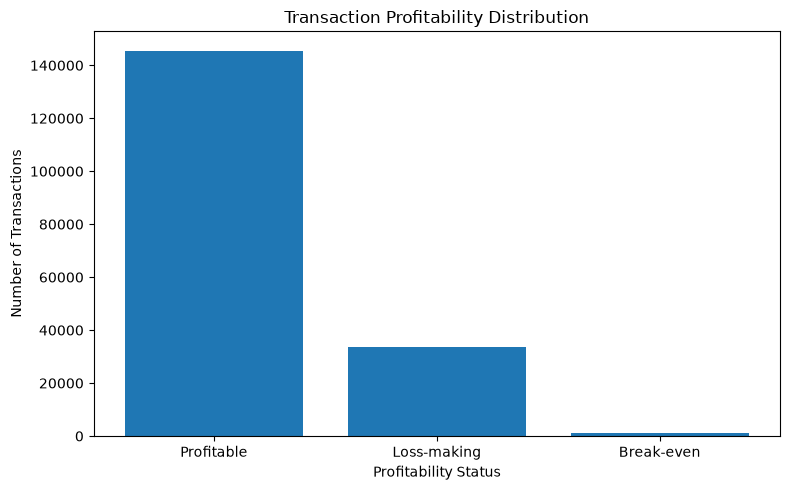

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    profitability_counts["Profitability Status"],
    profitability_counts["Transactions"]
)

plt.title("Transaction Profitability Distribution")
plt.xlabel("Profitability Status")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [8]:
# Revenue distribution

df["Sales"].describe()

count   180,519.00
mean        203.77
std         132.27
min           9.99
25%         119.98
50%         199.92
75%         299.95
max       1,999.99
Name: Sales, dtype: float64

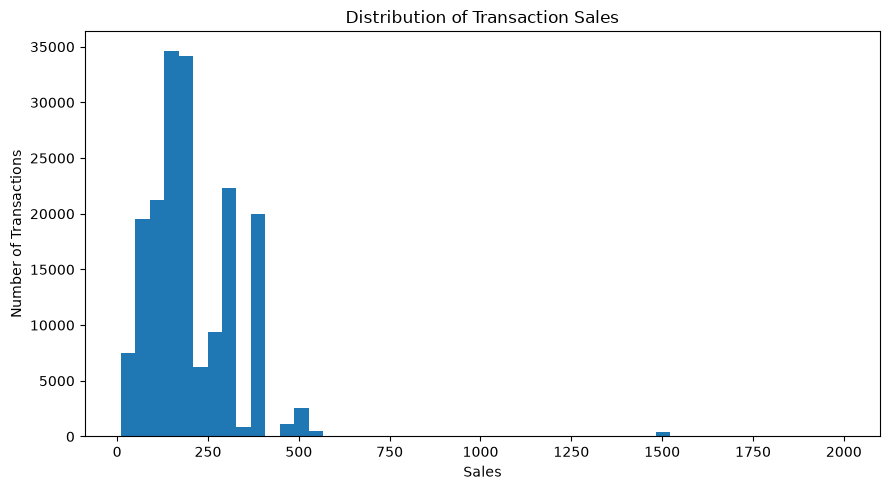

In [9]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Sales"],
    bins=50
)

plt.title("Distribution of Transaction Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [10]:
# Profit distribution

df["Order Profit Per Order"].describe()

count   180,519.00
mean         21.97
std         104.43
min      -4,274.98
25%           7.00
50%          31.52
75%          64.80
max         911.80
Name: Order Profit Per Order, dtype: float64

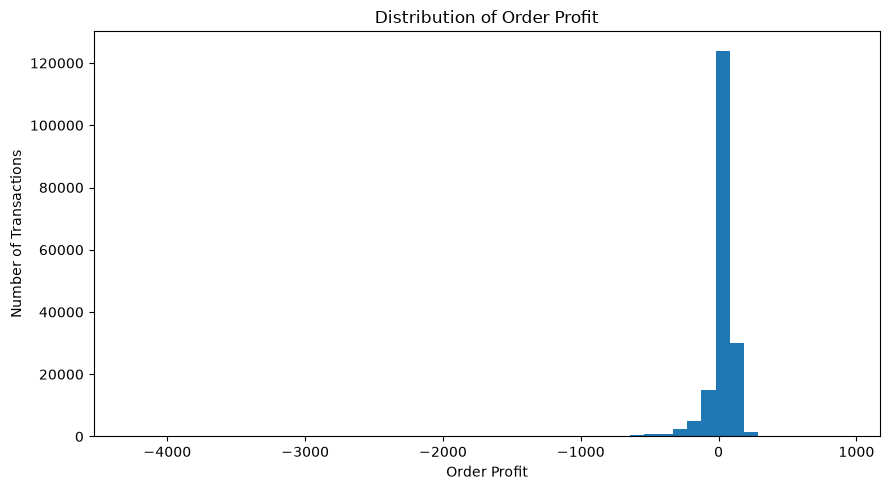

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Order Profit Per Order"],
    bins=50
)

plt.title("Distribution of Order Profit")
plt.xlabel("Order Profit")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [12]:
#Profit margin at transaction level

df["Transaction Profit Margin"] = (
    df["Order Profit Per Order"] /
    df["Order Item Total"]
)

In [13]:
df["Transaction Profit Margin"].describe()

count   180,519.00
mean          0.12
std           0.47
min          -2.75
25%           0.07
50%           0.27
75%           0.36
max           0.50
Name: Transaction Profit Margin, dtype: float64

In [14]:
invalid_margin = df[
    ~np.isfinite(df["Transaction Profit Margin"])
]

print(f"Invalid transaction margins: {len(invalid_margin):,}")

Invalid transaction margins: 0


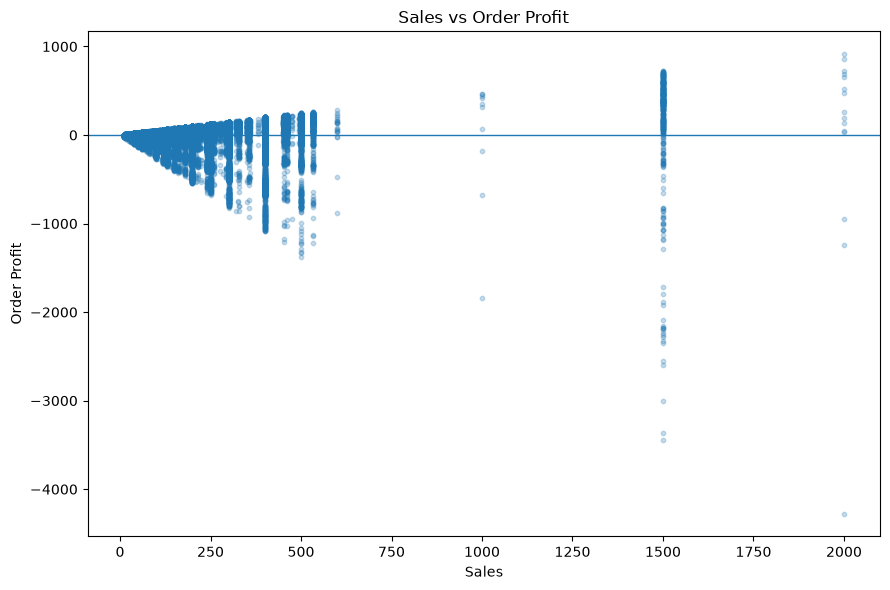

In [15]:
# Revenue vs Profit relationship

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Sales"],
    df["Order Profit Per Order"],
    alpha=0.25,
    s=10
)

plt.axhline(0, linewidth=1)

plt.title("Sales vs Order Profit")
plt.xlabel("Sales")
plt.ylabel("Order Profit")

plt.tight_layout()
plt.show()

In [16]:
# Calculate correlation

sales_profit_correlation = df[
    ["Sales", "Order Profit Per Order"]
].corr()

sales_profit_correlation

,Sales,Order Profit Per Order
Sales,1.00,0.13
Order Profit Per Order,0.13,1.00


In [17]:
correlation =df["Sales"].corr(
    df["Order Profit Per Order"]
)

print(f"Sales-Profit correlation: {correlation:.4f}")

Sales-Profit correlation: 0.1318


In [18]:
# Profit concentration

profitable_profit = df.loc[
    df["Order Profit Per Order"] > 0,
    "Order Profit Per Order"
].sum()

loss_amount = df.loc[
    df["Order Profit Per Order"] < 0,
    "Order Profit Per Order"
].sum()

break_even_count = (
    df["Order Profit Per Order"] == 0
).sum()

print(f"Profit from profitable transactions: ${profitable_profit:,.2f}")
print(f"Loss from loss-making transactions: ${loss_amount:,.2f}")
print(f"Break-even transactions: {break_even_count:,}")
print(f"Net profit: ${total_profit:,.2f}")

Profit from profitable transactions: $7,850,450.32
Loss from loss-making transactions: $-3,883,547.35
Break-even transactions: 1,177
Net profit: $3,966,902.97


In [19]:
# Discount exposure

discount_summary = pd.DataFrame({
    "Metric": [
        "Total Discount",
        "Discount as % of Revenue",
        "Average Discount per Transaction",
        "Transactions with Discount",
        "Transactions without Discount"
    ],
    "Value": [
        total_discount,
        discount_rate,
        df["Order Item Discount"].mean(),
        (df["Order Item Discount"] > 0).sum(),
        (df["Order Item Discount"] == 0).sum()
    ]
})

discount_summary

,Metric,Value
0,Total Discount,"3,730,378.40"
1,Discount as % of Revenue,0.10
2,Average Discount per Transaction,20.66
3,Transactions with Discount,"170,491.00"
4,Transactions without Discount,"10,028.00"


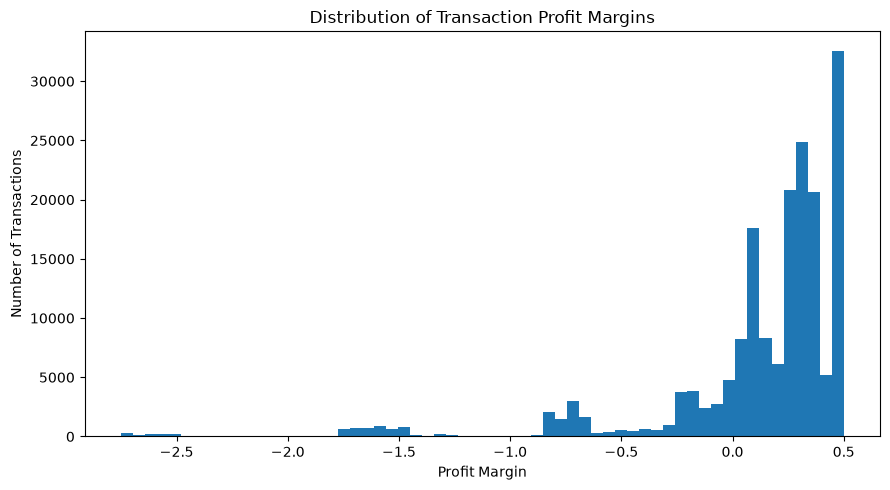

In [20]:
# Profit margin distribution 

plt.figure(figsize=(9, 5))

plt.hist(
    df["Transaction Profit Margin"],
    bins=60
)

plt.title("Distribution of Transaction Profit Margins")
plt.xlabel("Profit Margin")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [21]:
# Identify extreme margins

df[
    [
        "Product Name",
        "Category Name",
        "Sales",
        "Order Item Discount",
        "Order Item Total",
        "Order Profit Per Order",
        "Transaction Profit Margin"
    ]
].sort_values(
    "Transaction Profit Margin"
).head(10)

,Product Name,Category Name,Sales,Order Item Discount,Order Item Total,Order Profit Per Order,Transaction Profit Margin
179465,Toys,Toys,11.54,2.31,9.23,-25.39,-2.75
162142,adidas Men's Germany Black Crest Away Tee,Girls' Apparel,25.00,2.50,22.50,-61.88,-2.75
49526,adidas Men's F10 Messi TRX FG Soccer Cleat,Baseball & Softball,59.99,7.80,52.19,-143.53,-2.75
102169,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,49.98,8.00,41.98,-115.45,-2.75
119501,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel,50.00,7.50,42.50,-116.88,-2.75
146235,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,49.98,6.00,43.98,-120.95,-2.75
2223,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,99.99,16.00,83.99,-230.98,-2.75
72210,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,199.92,35.99,163.93,-450.82,-2.75
13144,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,199.92,31.99,167.93,-461.82,-2.75
29546,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,129.99,23.40,106.59,-293.13,-2.75


In [22]:
df[
    [
        "Product Name",
        "Category Name",
        "Sales",
        "Order Item Discount",
        "Order Item Total",
        "Order Profit Per Order",
        "Transaction Profit Margin"
    ]
].sort_values(
    "Transaction Profit Margin",
    ascending=False
).head(10)

,Product Name,Category Name,Sales,Order Item Discount,Order Item Total,Order Profit Per Order,Transaction Profit Margin
89150,Clicgear 8.0 Shoe Brush,Golf Gloves,9.99,1.80,8.19,4.10,0.50
172595,CDs of rock,CDs,11.29,2.26,9.03,4.52,0.50
177639,CDs of rock,CDs,11.29,1.92,9.37,4.69,0.50
41657,Clicgear 8.0 Shoe Brush,Golf Gloves,9.99,0.20,9.79,4.90,0.50
132194,Clicgear 8.0 Shoe Brush,Golf Gloves,9.99,0.10,9.89,4.95,0.50
179438,Toys,Toys,11.54,0.81,10.73,5.37,0.50
176707,Toys,Toys,11.54,0.35,11.19,5.60,0.50
172647,CDs of rock,CDs,11.29,0.00,11.29,5.65,0.50
1733,Glove It Urban Brick Golf Towel,Trade-In,15.99,4.00,11.99,6.00,0.50
133078,Glove It Urban Brick Golf Towel,Trade-In,15.99,2.40,13.59,6.80,0.50


## Temporal Analysis Limitation

The dataset does not contain a transaction date or order date field.
Consequently, genuine monthly, quarterly, or year-over-year revenue and
profit trends cannot be calculated from the supplied data.

The analysis therefore focuses on cross-sectional profitability patterns,
including transaction, customer, product, category, market, regional,
and discount-level comparisons.

No artificial time variable is introduced.

In [23]:
# Save the analytical dataset

analysis_path = "../data/processed/apl_logistics_eda.csv"

df.to_csv(
    analysis_path,
    index=False
)

print(f"EDA dataset saved to: {analysis_path}")

EDA dataset saved to: ../data/processed/apl_logistics_eda.csv


## Key Findings from Revenue & Profitability EDA

### 1. Overall financial performance

The dataset represents approximately $36.78 million in sales and $3.97
million in aggregate order profit, producing an overall profit margin of
10.78%.

### 2. Loss-making transactions

Although 80.63% of transactions are profitable, 18.71% are loss-making
and 0.65% are break-even. Loss-making transactions therefore represent
a substantial component of the transaction population and require
further investigation.

### 3. Profit offset from loss-making transactions

Profitable transactions generate approximately $7.85 million in profit,
while loss-making transactions contribute approximately $3.88 million
in negative profit. The losses therefore materially reduce the profit
generated by profitable transactions.

### 4. Revenue does not directly explain profitability

The Pearson correlation between transaction sales and order profit is
0.1318. This indicates a weak positive linear relationship between sales
and profit at transaction level. Further analysis is required to
understand the contribution of customers, products, discounts, and
markets.

### 5. Discount exposure

Total recorded discounts amount to approximately $3.73 million,
equivalent to 10.14% of total sales. Discount impact will be examined
in greater detail in the dedicated Discount Impact Analysis.

### 6. Temporal limitation

The dataset does not contain a transaction date, so monthly, quarterly,
and year-over-year financial trends cannot be calculated from the
available data.